## **Import libraries**

In [ ]:
import os
import random
import asyncio

SEED = 8
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import numpy as np
import pandas as pd

from natsort import natsorted
from collections import defaultdict

import torch
import torch.nn as nn
from transformers import set_seed as transformers_set_seed

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

def seed_everything(seed: int = SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    transformers_set_seed(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    torch.use_deterministic_algorithms(True)

seed_everything(SEED)

from SARVI.config import (
    paths
)
from SARVI.models.schemas import (
    PipelineContext,
    DOCXToJSONSConfig,
    LLMConfig
)
from SARVI.models.losses import (
    MoMLoss
)

from SARVI.data_io.reader import (
    textwrap,
    read_txt_list, read_ann_list,
    read_json_single,
    read_excel_single
)
from SARVI.data_io.writing import (
    write_torch_checkpoint, write_json_extra_docs, write_parquet
)

from SARVI.services.common.llm_loader import (
    load_llm
)
from SARVI.services.common.tree_funcs import (
    load_tree_hierarchical_module
)
from SARVI.services.common.llm_funcs import (
    prompts as prompts_total
)
from SARVI.services.common.ner_funcs import(
    tokenizer_ner, model_ner, initialize_span_ner_model
)
from SARVI.services.sync_funcs.ner_funcs import (
    prepare_data as prepare_data_SYNC,
    construct_loaders_ner as construct_loaders_ner_SYNC,
    run_span_nerclassifier as run_span_nerclassifier_SYNC
)

WARNING 05-28 18:05:02 [config.py:70] Support for Transformers v4 is deprecated. The Transformers v4 codepath will become unmaintained in vLLM v0.22.0 and will be removed in vLLM v0.24.0. Please upgrade to Transformers v5: pip install --upgrade transformers


Some weights of XLMRobertaModel were not initialized from the model checkpoint at IIC/RigoBERTa-Clinical and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## **Initialize variables**

In [ ]:
def initialize_variables(ctx: PipelineContext):
    print("0. Initializing variables\n")
    # create_intermediate_folder_name(ctx)

    #################################################################################################################

    if ctx.cie_10_version == "2018":
        df_reference = read_excel_single(ctx, "Diagnosticos_ES2018.xlsx", sheet_name="finales", header=0)
        df_reference = df_reference[['codigo', 'descripcion']].reset_index(drop=True).rename(columns={'codigo': 'Código', 'descripcion': 'Descripción'})
        df_reference["Código"] = (df_reference["Código"].astype(str).str.strip().str.replace("\xa0", "", regex=False))
        df_reference = df_reference[df_reference["Código"].str.match(r"^[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?(?:-[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?)?$")]

    elif ctx.cie_10_version == "2024":
        df_reference = read_excel_single(ctx, "Diagnosticos_ES2024.xlsx", sheet_name="ES2024 Completa + Marcadores", header=0)
        df_reference = df_reference[["Código", "Descripción"]].reset_index(drop=True)
        df_reference["Código"] = (df_reference["Código"].astype(str).str.strip().str.replace("\xa0", "", regex=False))
        df_reference = df_reference[df_reference["Código"].str.match(r"^[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?(?:-[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?)?$")]

    else:
        df_reference = read_excel_single(ctx, "Diagnosticos_ES2026.xlsx", sheet_name="ES2026 Completa + Marcadores", header=0)
        df_reference = df_reference[["Código", "Descripción"]].reset_index(drop=True)
        df_reference["Código"] = (df_reference["Código"].astype(str).str.strip().str.replace("\xa0", "", regex=False))
        df_reference = df_reference[df_reference["Código"].str.match(r"^[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?(?:-[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?)?$")]

    #################################################################################################################

    report_list = natsorted(p for p in (ctx.paths.data_input / ctx.folder_and_archive_name).iterdir() if p.is_file())
    
    if ctx.ussage == "generative":
        llm = load_llm(ctx.llm_config)
        prompt = textwrap.dedent(prompts_total["report_to_data"])
        modelo_ner = None
        node_list = None
        modelo_icd10_head = None
        modelo_icd10_prediction = None
        label2id_ICD10 = None
        id2label_ICD10 = None
        id_no_hs_to_id_hs = None
        icd10_thresholds = None
    else:
        llm = None
        prompt = None
        modelo_ner = [None, None]
        node_list = load_tree_hierarchical_module(df_reference)

        root = node_list["root"]
        root.set_indexes()
        label2id_hs = {key.name: value for key, value in root.node_to_id.items()}
        id2label_hs = {value: key for key, value in label2id_hs.items()}
        label2id_no_hs = {id2label_hs[value.item()]: i for i, value in enumerate(root.leaf_indexes)}
        id2label_no_hs = {value: key for key, value in label2id_no_hs.items()}
        label2id_ICD10 = [label2id_hs, label2id_no_hs]
        id2label_ICD10 = [id2label_hs, id2label_no_hs]
        id_no_hs_to_id_hs = {id_no_hs: label2id_hs[label_name] for label_name, id_no_hs in label2id_no_hs.items()}

        # modelo_icd10_head = [initialize_icd10_hs_head_model(ctx, "ICD10_HS_checkpoint.pt", root), initialize_icd10_no_hs_head_model(ctx, "ICD10_NO_HS_checkpoint.pt", label2id_no_hs, root)]
        # modelo_icd10_prediction = [initialize_icd10_hs_prediction_model(ctx, "ICD10_HS_checkpoint.pt", label2id_hs, root), None]
        modelo_icd10_head = None
        modelo_icd10_prediction = None
        icd10_thresholds = read_json_single(ctx.paths.docs_dir / "thresholds_ICD10.json")
    
    semaforo = asyncio.Semaphore(ctx.MAX_CONCURRENCY)

    config = DOCXToJSONSConfig(
        report_list=report_list,
        prompt=prompt,
        llm=llm,
        semaforo=semaforo,
        modelo_ner=modelo_ner,
        node_list=node_list,
        modelo_icd10_head=modelo_icd10_head,
        modelo_icd10_prediction=modelo_icd10_prediction,
        label2id_ICD10=label2id_ICD10,
        id2label_ICD10=id2label_ICD10,
        id_no_hs_to_id_hs=id_no_hs_to_id_hs,
        icd10_thresholds=icd10_thresholds
    )

    return config

In [3]:
llm_config = LLMConfig(
    service="vllm",
    model="openai/gpt-oss-20b",
    device="cuda" if torch.cuda.is_available() else "cpu"
)

ctx = PipelineContext(
    ussage="deterministic",
    # folder_and_archive_name="CT-EBM-SP-v3/train",
    folder_and_archive_name="CT-EBM-SP-v3/train",
    llm_config=llm_config,
    paths=paths,
    cie_10_version="2026",
    json_parse=False,
    device = "cuda" if torch.cuda.is_available() else "cpu"
)

config = initialize_variables(ctx)

0. Initializing variables



Hierarchical tree construction: Cleaning data:   0%|          | 0/102426 [00:00<?, ?code/s]

## **Run SPAN NER data creation**

### **Create data**

In [4]:
print("1.1. Creating NER data // Train data")
dict_data_train = read_txt_list(ctx.paths.data_input / ctx.folder_and_archive_name)
df_data_train = pd.DataFrame(list(dict_data_train.items()), columns=["archivo_origen", "Text"])

dict_ann_train = read_ann_list(ctx.paths.data_input / ctx.folder_and_archive_name)
df_ann_train = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_train.items()])
# df_ann = None

data_prepared_train, all_window_labels_train, file_names_train = prepare_data_SYNC(df_data_train, data_ann=df_ann_train, padding=True, tokenizer=tokenizer_ner, model=model_ner, device=ctx.device, lemma=True)

print("1.1. Creating NER data // Dev data")
dict_data_dev = read_txt_list(ctx.paths.data_input / "CT-EBM-SP-v3/dev")
df_data_dev = pd.DataFrame(list(dict_data_dev.items()), columns=["archivo_origen", "Text"])

dict_ann_dev = read_ann_list(ctx.paths.data_input / "CT-EBM-SP-v3/dev")
df_ann_dev = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_dev.items()])
# df_ann = None

data_prepared_dev, all_window_labels_dev, file_names_dev = prepare_data_SYNC(df_data_dev, data_ann=df_ann_dev, padding=True, tokenizer=tokenizer_ner, model=model_ner, device=ctx.device, lemma=True)

1.1. Creating NER data // Train data


Preparing data for NER prediction: Window slicing and overlapping tokens:   0%|          | 0/720 [00:00<?, ?te…

Token indices sequence length is longer than the specified maximum sequence length for this model (549 > 512). Running this sequence through the model will result in indexing errors


1.1. Creating NER data // Dev data


Preparing data for NER prediction: Window slicing and overlapping tokens:   0%|          | 0/240 [00:00<?, ?te…

> Example of label output

In [5]:
all_window_labels_dev

[[['O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   '1_B-LIVB',
   'O',
   '2_B-DISO',
   '2_I-DISO',
   '2_I-DISO',
   '2_I-DISO',
   '2_I-DISO',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   '3_B-DISO',
   '3_B-DISO',
   '3_B-DISO',
   '3_I-DISO',
   '3_I-DISO',
   '3_I-DISO',
   '3_I-DISO',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   '4_B-LIVB',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O',
   'O'

In [6]:
### Example of labels
example_window_labels = all_window_labels_train[2][0]
example_data_prepared = data_prepared_train[2][0]["input_ids"]

for i,(label,token) in enumerate(zip(example_window_labels,tokenizer_ner.convert_ids_to_tokens(example_data_prepared))):
    if label != "O":
        print(f"{label}: {token}")
        if i+1 <= len(example_window_labels) and example_window_labels[i+1] == "O":
            print()

1_B-Date: ▁2016-
1_B-Date: 0000
1_B-Date: 71
1_B-Date: -24

2_B-DISO: ▁sang
2_B-DISO: rado

3_B-DISO: ▁sang
3_B-DISO: rado

4_B-DISO: ▁sang
4_B-DISO: rado

5_B-LIVB: ▁paciente
5_I-LIVB: ▁adult
5_I-LIVB: o
5_I-LIVB: ▁de
5_I-LIVB: ▁ambos
5_I-LIVB: ▁sexo

6_B-LIVB: ▁paciente

7_B-DISO: ▁is
7_B-DISO: que
7_B-DISO: mia

8_B-LIVB: ▁paciente

9_B-Spec_cue: ▁riesgo
9_I-Spec_cue: ▁de

10_B-LIVB: ▁mujer
10_I-LIVB: ▁fér
10_I-LIVB: til

11_B-Neg_cue: ▁no

12_B-DISO: ▁alergi
12_B-DISO: a

13_B-DISO: ▁hiper
13_B-DISO: sensi
13_B-DISO: bilidad

14_B-DISO: ▁trastorno
14_I-DISO: ▁adquirido
14_I-DISO: ▁o
14_I-DISO: ▁con
14_I-DISO: gén
14_I-DISO: ito
14_I-DISO: ▁de
14_I-DISO: ▁el
14_I-DISO: ▁coa
14_I-DISO: gula
14_I-DISO: ción

15_B-DISO: ▁trombo
15_B-DISO: filia

16_B-DISO: ▁trombo
16_B-DISO: sis
16_I-DISO: ▁arterial
16_I-DISO: ▁o
16_I-DISO: ▁ven
16_I-DISO: oso

17_B-DISO: ▁trombo
17_B-DISO: e
17_B-DISO: mbol
17_B-DISO: ismo
17_I-DISO: ▁pulmonar

18_B-DISO: ▁fi
18_B-DISO: bril
18_B-DISO: ación
18_I-DISO

> Total count of labels

In [7]:
labels_unique = defaultdict(int)
for i in [i for window in all_window_labels_train for sublist in window for i in sublist]:
    labels_unique[i] += 1


bio_order = {"B": 0, "I": 1, "O": 2}
ordered_data = defaultdict(labels_unique.default_factory, sorted(labels_unique.items(), key=lambda x:(x[0].split("-", 1)[1] if "-" in x[0] else x[0], bio_order.get(x[0].split("-", 1)[0], 99))))
ordered_data

defaultdict(int,
            {'3_B-DISO': 860,
             '4_B-DISO': 690,
             '6_B-DISO': 727,
             '7_B-DISO': 741,
             '4_I-DISO': 786,
             '7_I-DISO': 810,
             '8_B-DISO': 730,
             '8_I-DISO': 739,
             '2_B-DISO': 659,
             '12_B-DISO': 712,
             '13_B-DISO': 749,
             '14_B-DISO': 704,
             '14_I-DISO': 605,
             '15_B-DISO': 706,
             '16_B-DISO': 681,
             '16_I-DISO': 477,
             '17_B-DISO': 682,
             '17_I-DISO': 547,
             '18_B-DISO': 565,
             '18_I-DISO': 552,
             '19_B-DISO': 560,
             '19_I-DISO': 473,
             '20_B-DISO': 625,
             '21_B-DISO': 504,
             '2_I-DISO': 739,
             '5_B-DISO': 767,
             '5_I-DISO': 865,
             '22_B-DISO': 456,
             '24_B-DISO': 419,
             '28_B-DISO': 275,
             '30_B-DISO': 263,
             '30_I-DISO': 248,
   

### **Create DataLoaders and models**

In [8]:
seed_everything(SEED)

dataset_full_train, data_loader_full_train, label2id, id2label = construct_loaders_ner_SYNC(data_prepared_train, all_window_labels_train, file_names_train, ner_type="span", seed=SEED, ignore_o_labels=False, batch_size=1)
dataset_full_dev, data_loader_full_dev, _, _ = construct_loaders_ner_SYNC(data_prepared_dev, all_window_labels_dev, file_names_dev, ner_type="span", label2id=label2id, id2label=id2label, seed=SEED, ignore_o_labels=False, batch_size=1)

source_label2id = read_json_single(ctx.paths.docs_dir / "NERTraining/Span/E3C/label2id_span_nerclassifier.json")
config.modelo_ner[0] = initialize_span_ner_model(ctx, model_ner, len(id2label), id2label, label2id, tokenizer_ner, "NERTraining/Span/E3C/span_nerclassifier_checkpoint.pt", True, source_label2id=source_label2id, target_label2id=label2id)
ignore_index = -100

optimizer = torch.optim.AdamW(config.modelo_ner[0].parameters(), lr=2e-5, weight_decay=0.001)
criterion = MoMLoss(M=512, majority_label=label2id["O"], delta=0.05,
                    # sentence_loss_fn=DiceLoss(epsilon=1.0, delta=0.01), 
                    sentence_loss_fn=nn.CrossEntropyLoss(reduction="none", ignore_index=ignore_index),
                    majority_loss_fn=nn.CrossEntropyLoss(reduction="none", ignore_index=ignore_index),
                    ignore_index=ignore_index)

### **Train model**

In [9]:
seed_everything(SEED)

print("1.2. Running NER model // SPAN")
results = run_span_nerclassifier_SYNC(config.modelo_ner[0], data_loader=data_loader_full_train, device=ctx.device, id2label=id2label, train=True, dev_data_loader=data_loader_full_dev, optimizer=optimizer, criterion=criterion, epochs=100, patience=10, ignore_index=ignore_index, return_predictions=False)

write_torch_checkpoint(ctx=ctx, name="NERTraining/Span/CT-EBM-SP/span_nerclassifier_checkpoint", checkpoint=results["best_model_state"])
write_parquet(ctx=ctx, name="NERTraining/Span/CT-EBM-SP/span_nerclassifier_results", data=pd.DataFrame([{k: (v.tolist() if hasattr(v, "tolist") else v) for k, v in results.items() if k not in ["best_model_state", "model_outputs"]}]))
write_json_extra_docs(ctx=ctx, file_name="NERTraining/Span/CT-EBM-SP/id2label_span_nerclassifier", content=id2label)
write_json_extra_docs(ctx=ctx, file_name="NERTraining/Span/CT-EBM-SP/label2id_span_nerclassifier", content=label2id)

1.2. Running NER model // SPAN


Span NER / Training:   0%|          | 0/100 [00:00<?, ?epoch/s]

Span NER / Training epoch 1 / Train set:   0%|          | 0/720 [00:00<?, ?batch/s]

Span NER / Training epoch 1 / Dev set:   0%|          | 0/240 [00:00<?, ?batch/s]


Development classification report:
              precision    recall  f1-score   support

           O     0.9743    0.9970    0.9855     97168
        DISO     0.9641    0.7961    0.8721      8633
        Date     0.8832    0.6556    0.7526       392
        LIVB     0.9605    0.8014    0.8738      2916
     Neg_cue     1.0000    0.3282    0.4943       131
    Spec_cue     0.9231    0.1176    0.2087       102

    accuracy                         0.9730    109342
   macro avg     0.9509    0.6160    0.6978    109342
weighted avg     0.9727    0.9730    0.9714    109342

Epoch 1/100 | train loss: 0.017893 | dev loss: 0.013285 | Best F1 (macro): 0.6978


...

Span NER / Training epoch 20 / Dev set:   0%|          | 0/240 [00:00<?, ?batch/s]


Development classification report:
              precision    recall  f1-score   support

           O     0.9899    0.9929    0.9914     97168
        DISO     0.9306    0.9077    0.9190      8633
        Date     0.8840    0.8750    0.8795       392
        LIVB     0.9693    0.9424    0.9557      2916
     Neg_cue     0.9402    0.8397    0.8871       131
    Spec_cue     0.8246    0.9216    0.8704       102

    accuracy                         0.9842    109342
   macro avg     0.9231    0.9132    0.9172    109342
weighted avg     0.9841    0.9842    0.9841    109342

Epoch 20/100 | train loss: 0.001094 | dev loss: 0.037403 | Best F1 (macro): 0.9205


Span NER / Training epoch 21 / Train set:   0%|          | 0/720 [00:00<?, ?batch/s]

Span NER / Training epoch 21 / Dev set:   0%|          | 0/240 [00:00<?, ?batch/s]


Development classification report:
              precision    recall  f1-score   support

           O     0.9858    0.9961    0.9909     97168
        DISO     0.9615    0.8675    0.9121      8633
        Date     0.8789    0.8699    0.8744       392
        LIVB     0.9768    0.9372    0.9566      2916
     Neg_cue     0.9787    0.7023    0.8178       131
    Spec_cue     0.9072    0.8627    0.8844       102

    accuracy                         0.9834    109342
   macro avg     0.9482    0.8726    0.9060    109342
weighted avg     0.9832    0.9834    0.9831    109342


Early stopping at epoch 21 | Best epoch: 11 | Best dev macro F1: 0.920509


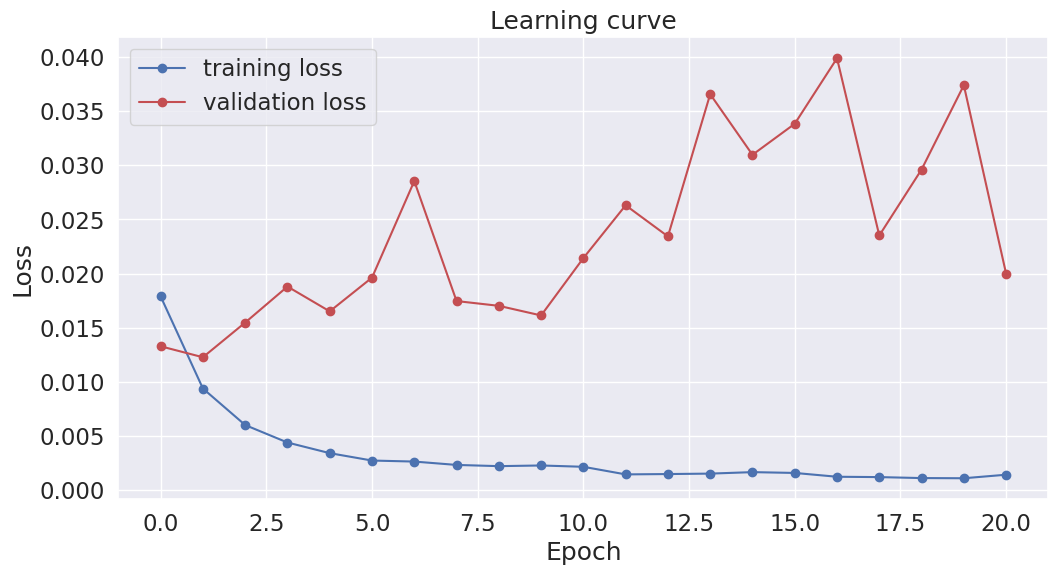

In [10]:
# Use plot styling from seaborn.
sns.set(style='darkgrid')

# Increase the plot size and font size.
sns.set(font_scale=1.5)
plt.rcParams["figure.figsize"] = (12,6)

# Plot the learning curve.
plt.plot(results["loss_values"], 'b-o', label="training loss")
plt.plot(results["development_loss_values"], 'r-o', label="validation loss")

# Label the plot.
plt.title("Learning curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

### **Eval model**

In [11]:
print("1.1. Creating NER data // Test data")
# dict_data_test = read_txt_list(ctx.paths.data_input / "CT-EBM-SP-v3/test")
dict_data_test = read_txt_list(ctx.paths.data_input / "CT-EBM-SP-v2/test")
df_data_test = pd.DataFrame(list(dict_data_test.items()), columns=["archivo_origen", "Text"])

# dict_ann_test = read_ann_list(ctx.paths.data_input / "CT-EBM-SP-v3/test")
dict_ann_test = read_ann_list(ctx.paths.data_input / "CT-EBM-SP-v2/test")
df_ann_test = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_test.items()])
# df_ann = None

data_prepared_test, all_window_labels_test, file_names_test = prepare_data_SYNC(df_data_test, data_ann=df_ann_test, padding=True, tokenizer=tokenizer_ner, model=model_ner, device=ctx.device)

1.1. Creating NER data // Test data


Preparing data for NER prediction: Window slicing and overlapping tokens:   0%|          | 0/240 [00:00<?, ?te…

In [12]:
id2label = read_json_single(ctx.paths.docs_dir / "NERTraining/Span/CT-EBM-SP/id2label_span_nerclassifier.json")
label2id = read_json_single(ctx.paths.docs_dir / "NERTraining/Span/CT-EBM-SP/label2id_span_nerclassifier.json")
id2label = {int(k): v for k, v in id2label.items()}
label2id = {v: int(k)  for k, v in id2label.items()}

dataset_full_test, data_loader_full_test, _, _ = construct_loaders_ner_SYNC(data_prepared_test, all_window_labels_test, file_names_test, ner_type="span", label2id=label2id, id2label=id2label, seed=SEED, ignore_o_labels=False, batch_size=1)

config.modelo_ner[0] = initialize_span_ner_model(ctx, model_ner, len(id2label), id2label, label2id, tokenizer_ner, "NERTraining/Span/CT-EBM-SP/span_nerclassifier_checkpoint.pt", True)

In [13]:
results = run_span_nerclassifier_SYNC(config.modelo_ner[0], data_loader=data_loader_full_test, device=ctx.device, id2label=id2label, train=False)

Span NER / Inference:   0%|          | 0/240 [00:00<?, ?batch/s]


Classification report:
              precision    recall  f1-score   support

           O     0.9884    0.9958    0.9921    106348
        DISO     0.9630    0.8714    0.9149      7798
        Date     0.6667    0.8323    0.7403       310
        LIVB     0.9624    0.9441    0.9532      2846
     Neg_cue     0.9688    0.6200    0.7561       100
    Spec_cue     0.9364    0.7254    0.8175       142

    accuracy                         0.9852    117544
   macro avg     0.9143    0.8315    0.8623    117544
weighted avg     0.9852    0.9852    0.9850    117544



## **Results to .ann format**

In [14]:
from SARVI.services.common.utils.ann_utils import ner_outputs_to_ann
from SARVI.data_io.writing import write_ann_list

In [15]:
ann_format = ner_outputs_to_ann(results, id2label, data_loader=data_loader_full_test, original_texts=df_data_test, tokenizer=tokenizer_ner)
# write_ann_list(ctx, ann_format, ctx.paths.data_intermediate / ctx.folder_and_archive_name / "span", extra="")
write_ann_list(ctx, ann_format, ctx.paths.data_intermediate / "CT-EBM-SP-v2/test" / "span", extra="")

## **NER results**

In [16]:
from SARVI.services.common.ner_funcs import classification_report_ner

In [17]:
# dict_ann_test_true = read_ann_list(ctx.paths.data_input / "CT-EBM-SP-v3/test")
dict_ann_test_true = read_ann_list(ctx.paths.data_input / "CT-EBM-SP-v2/test")
df_ann_test_true = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_test_true.items()])

# dict_ann_test_pred = read_ann_list(ctx.paths.data_intermediate / ctx.folder_and_archive_name / "span")
dict_ann_test_pred = read_ann_list(ctx.paths.data_intermediate / "CT-EBM-SP-v2/test" / "span")
df_ann_test_pred = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_test_pred.items()])

label2id = read_json_single(ctx.paths.docs_dir / "NERTraining/Span/CT-EBM-SP/label2id_span_nerclassifier.json")

In [18]:
results = classification_report_ner(df_ann_test_true, df_ann_test_pred, [k for k in label2id.keys() if k != "O"])

              precision    recall  f1-score   support   type_1   type_2   type_3   type_4   type_5

        DISO     0.8354    0.7580    0.7948      2550        1      229        9        7      372
        Date     0.3537    0.2437    0.2886       357        1      126        2        1      141
        LIVB     0.8930    0.8512    0.8716      1687        0       97        3        3      148
     Neg_cue     0.3462    0.0347    0.0632       518        0      439        3       24       34
    Spec_cue     0.4211    0.2299    0.2974       174        0       82        2        3       47

   micro avg     0.8144    0.6648    0.7320      5286        2      973       19       38      742
   macro avg     0.5698    0.4235    0.4631      5286        2      973       19       38      742
weighted avg     0.7597    0.6648    0.6971      5286        2      973       19       38      742
